# 01 — Vertical Slice: audio → transcript → features → score → evaluation

**Goal:** run ~100 real learner spoken responses through the *entire* scoring pipeline and get our
first honest evaluation numbers against human ratings — before building anything properly.

```
  flac audio ──▶ Whisper ASR ──▶ transcript + word timestamps
                                        │
                                        ▼
                            10 hand-built fluency features
                                        │
                                        ▼
                     Ridge regression (vs a word-count-only baseline)
                                        │
                                        ▼
        evaluation vs human scores: correlation, MAE/RMSE, weighted kappa
```

**Why a vertical slice first?** Each stage above hides surprises (ASR quirks, timestamp gaps,
score-scale details). Touching every stage with minimal effort surfaces those surprises *now*,
while changing course is free. Notebooks 02–04 then rebuild each stage properly in `src/`.

**Data:** Speak & Improve Corpus 2025, dev set, **Part 3 only** — one ~60-second long turn per
speaker, so each audio file aligns with exactly one human score. Cleanest possible label join.

> ⚠️ **Licence rule:** the corpus is research-licensed. This notebook deliberately displays only
> *aggregates* (counts, distributions, metrics) — never transcripts, speaker IDs, or per-response
> rows. Keep it that way, and clear outputs before committing if you add exploratory cells.

## Step 1 — Configuration

Everything tunable lives here. Two parameters matter most:

- **`N_SAMPLE = 100`** — enough to see real signal, small enough that transcription takes
  ~10–15 minutes on an M1 Pro.
- **`WHISPER_MODEL = "small"`** — the design doc's floor. `faster-whisper` (CTranslate2) runs
  Whisper ~8–10× realtime on CPU with `int8` quantisation, and doesn't need PyTorch — torch
  arrives later with the MLP, when we actually need it.

`SEED` is fixed so the sample, the cross-validation folds, and therefore every number in this
notebook are reproducible.

In [1]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd

# Resolve the project root whether the notebook runs from notebooks/ or the repo root
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
assert (ROOT / "data" / "sandi-corpus-2025").exists(), f"corpus not found under {ROOT}"

CORPUS = ROOT / "data" / "sandi-corpus-2025"
REF = CORPUS / "reference-materials"
DERIVED = ROOT / "data" / "derived"          # cache for transcripts — inside gitignored data/
DERIVED.mkdir(exist_ok=True)

PART = "P3"                  # one long turn per speaker -> one score per file
N_SAMPLE = 100
SEED = 42
WHISPER_MODEL = "small"
PAUSE_GAP = 0.3              # silence >= 0.3s between words counts as a pause
LONG_PAUSE = 1.0             # silence >= 1.0s counts as a long pause

print(f"project root: {ROOT.name}/  |  part: {PART}  |  sample: {N_SAMPLE}  |  model: {WHISPER_MODEL}")

project root: speech_scoring_evaluation_lab/  |  part: P3  |  sample: 100  |  model: small


## Step 2 — Load the human scores and the audio file list

Two corpus files get joined here:

1. **`sla-marks/dev-sla-P3.tsv`** — the labels. One row per *speaker*: `speakerID → score`.
   Scores are manual holistic ratings on a **0–6 scale at 0.5 intervals**, where integers map
   approximately to CEFR (1 = A1, 2 = A2, 3 = B1, 4 = B2, 5 = C1). Criteria follow the
   Linguaskill Speaking Global Assessment Criteria.
2. **`flists.flac/dev-sla-P3.tsv`** — the audio index. One row per *utterance*:
   `utteranceID → flac path`. For Part 3 there is exactly one utterance per speaker.

The join key: an utterance ID like `SIXXXX-00000-P30000` is the speaker ID `SIXXXX-00000`
plus a part/question suffix — so we split the suffix off and merge.

The histogram at the end is our first look at **label distribution** — it matters because a
model can score a deceptively good MAE on a narrow distribution by predicting the mean.

responses with scores: 438
score range: 2.0–5.5, mean 4.03, std 0.73


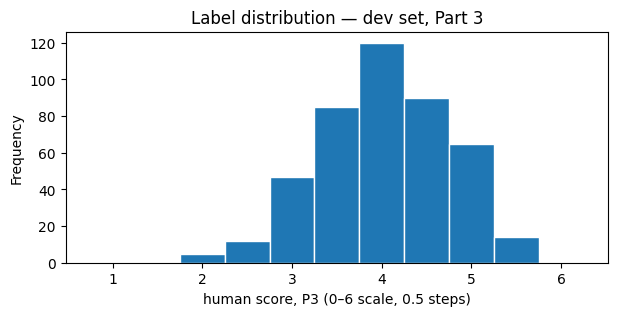

In [2]:
scores = pd.read_csv(REF / "sla-marks" / f"dev-sla-{PART}.tsv", sep="\t", names=["speaker", "score"])
flist = pd.read_csv(REF / "flists.flac" / f"dev-sla-{PART}.tsv", sep="\t", names=["utt", "flac"])

# utteranceID 'SIXXXX-00000-P30000' -> speakerID 'SIXXXX-00000'
flist["speaker"] = flist["utt"].str.rsplit("-", n=1).str[0]

df = flist.merge(scores, on="speaker", how="inner")
assert len(df) == len(scores) == len(flist), "expected a clean 1:1 speaker<->utterance join for P3"

print(f"responses with scores: {len(df)}")
print(f"score range: {df.score.min():.1f}–{df.score.max():.1f}, mean {df.score.mean():.2f}, std {df.score.std():.2f}")

ax = df.score.plot.hist(bins=np.arange(0.75, 6.5, 0.5), edgecolor="white", figsize=(7, 3))
ax.set_xlabel(f"human score, {PART} (0–6 scale, 0.5 steps)")
ax.set_title("Label distribution — dev set, Part 3");

## Step 3 — Sample 100 responses, stratified by score band

A *random* 100 would over-represent the middle of the distribution (most learners are B1–B2)
and might give us almost no A2 or C1 speakers. Since we specifically care how the scorer
behaves *across* proficiency levels, we sample proportionally within each integer score band
(**stratified sampling**) — every band keeps its share, and rare bands aren't accidentally
dropped entirely.

Note what we are *not* doing: no train/test split yet. With only 100 rows we'll use
cross-validation instead (Step 6).

In [3]:
df["band"] = df.score.clip(1, 5.99).astype(int)   # integer CEFR-ish band: 1=A1 .. 5=C1

sample = (
    df.groupby("band", group_keys=False)
      .apply(lambda g: g.sample(max(1, round(len(g) * N_SAMPLE / len(df))), random_state=SEED),
             include_groups=False)
)
sample = sample.sample(min(N_SAMPLE, len(sample)), random_state=SEED).reset_index(drop=True)

print(f"sampled: {len(sample)} responses")
print("\nband counts (full dev vs sample):")
print(pd.DataFrame({"dev": df.band.value_counts().sort_index(),
                    "sample": sample.merge(df[["utt", "band"]], on="utt").band.value_counts().sort_index()}))

sampled: 100 responses

band counts (full dev vs sample):
      dev  sample
band             
2      17       4
3     132      30
4     210      48
5      79      18


## Step 4 — Transcribe with Whisper (word timestamps on)

`faster-whisper` re-implements OpenAI's Whisper on the CTranslate2 inference engine — same
weights, ~8–10× faster on CPU. Two settings matter for *us*:

- **`word_timestamps=True`** — we need *when* each word was said, not just *what*. Every
  fluency feature in Step 5 (pauses, speech rate, length of run) is computed from these
  timestamps.
- **`language="en"`** — skips language detection. These are L2 *English* tests; letting the
  model guess invites it to switch language on strong-accented speakers, which would corrupt
  downstream features for exactly the speakers fairness analysis cares about.

**Caching:** transcription is the slow step (~10–15 min for 100 × ~60 s). Results are cached
as JSON in `data/derived/` (gitignored), keyed by utterance ID — re-running the notebook is
then instant. Delete the cache file to force re-transcription.

**A known limitation to remember for the report:** Whisper was trained to produce *clean*
text — it routinely drops filled pauses ("um", "uh") and smooths repetitions. Our
`filled_pauses` feature will therefore *undercount* badly. The corpus's gold disfluency
annotations let us quantify exactly how badly later — that's an error-analysis deliverable,
not a bug to fix today.

In [4]:
from faster_whisper import WhisperModel

CACHE = DERIVED / f"transcripts_{PART}_{WHISPER_MODEL}.json"
cache = json.loads(CACHE.read_text()) if CACHE.exists() else {}
todo = [r for r in sample.itertuples() if r.utt not in cache]
print(f"cached: {len(sample) - len(todo)}  |  to transcribe: {len(todo)}")

if todo:
    model = WhisperModel(WHISPER_MODEL, device="cpu", compute_type="int8")
    for i, row in enumerate(todo, 1):
        segments, _info = model.transcribe(str(CORPUS / row.flac), word_timestamps=True, language="en")
        words = [{"w": w.word.strip(), "s": round(w.start, 3), "e": round(w.end, 3)}
                 for seg in segments for w in seg.words]
        cache[row.utt] = words
        if i % 10 == 0 or i == len(todo):
            CACHE.write_text(json.dumps(cache))   # checkpoint every 10 files
            print(f"  {i}/{len(todo)} transcribed")

n_words_total = sum(len(v) for k, v in cache.items() if k in set(sample.utt))
print(f"done — {n_words_total} words across {len(sample)} responses (aggregate only, per licence)")

/Users/gavin.reid/gavin/speech_scoring_evaluation_lab/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cached: 0  |  to transcribe: 100


  10/100 transcribed


  20/100 transcribed


  30/100 transcribed


...

  60/100 transcribed


  70/100 transcribed


  80/100 transcribed


  90/100 transcribed


  100/100 transcribed
done — 9121 words across 100 responses (aggregate only, per licence)


## Step 5 — Hand-build 10 fluency features

This is the heart of the notebook. Each feature is a classic measure from the L2 fluency
literature, computed from nothing but **word timestamps** and the **audio duration**:

| # | Feature | What it measures | Why it should predict proficiency |
|---|---------|------------------|----------------------------------|
| 1 | `duration_sec` | total audio length | weak control variable — speaking time is fixed (~60 s), so deviations mean early stops |
| 2 | `n_words` | total words recognised | more proficient speakers simply say more in the same time |
| 3 | `speech_rate_wpm` | words ÷ total duration × 60 | the single most robust fluency predictor in the literature |
| 4 | `articulation_rate` | words ÷ *speaking* time × 60 | how fast you talk *when actually talking* — separates "slow speaker" from "frequent pauser" |
| 5 | `n_pauses` | count of silent gaps ≥ 0.3 s | pause *frequency* — hesitant planning |
| 6 | `total_pause_time` | summed silence ≥ 0.3 s | overall silence burden |
| 7 | `mean_pause_dur` | average pause length | long pauses signal lexical retrieval trouble |
| 8 | `n_long_pauses` | pauses ≥ 1.0 s | breakdown moments — strong negative signal |
| 9 | `mean_length_of_run` | mean words between pauses | longer uninterrupted runs = more automatised speech |
| 10 | `ttr` | unique words ÷ total words | lexical diversity proxy (length-sensitive — MTLD replaces it in notebook 02) |

(+ `filled_pauses` as a bonus 11th, kept despite the Whisper undercounting caveat from Step 4 —
seeing a *known-broken* feature get a near-zero coefficient is itself instructive.)

The 0.3 s pause threshold is the conventional choice in fluency research (de Jong & Bosker,
2013, are the standard citation); 0.25–0.4 s all appear in published work. It goes into the
config cell, not a magic number buried in code, precisely so we can test sensitivity later.

In [5]:
import soundfile as sf

FILLED = re.compile(r"^(um+|uh+|er+m?|eh+|h?mm+)$", re.IGNORECASE)

def fluency_features(words: list[dict], duration: float) -> dict:
    """Compute fluency features from Whisper word timestamps.

    words: [{'w': str, 's': start_sec, 'e': end_sec}, ...] in time order
    duration: audio file length in seconds
    """
    n = len(words)
    if n == 0:                       # silent / failed ASR -> all-zero row, flagged for exclusion
        return dict.fromkeys(
            ["duration_sec", "n_words", "speech_rate_wpm", "articulation_rate",
             "n_pauses", "total_pause_time", "mean_pause_dur", "n_long_pauses",
             "mean_length_of_run", "ttr", "filled_pauses"], 0.0) | {"duration_sec": duration}

    gaps = [w2["s"] - w1["e"] for w1, w2 in zip(words, words[1:])]
    pauses = [g for g in gaps if g >= PAUSE_GAP]
    phonation = sum(w["e"] - w["s"] for w in words)            # time spent actually speaking
    runs = np.split(np.arange(n), [i + 1 for i, g in enumerate(gaps) if g >= PAUSE_GAP])
    tokens = [re.sub(r"[^a-z']", "", w["w"].lower()) for w in words]
    tokens = [t for t in tokens if t]

    return {
        "duration_sec": duration,
        "n_words": n,
        "speech_rate_wpm": n / duration * 60,
        "articulation_rate": n / phonation * 60 if phonation > 0 else 0.0,
        "n_pauses": len(pauses),
        "total_pause_time": sum(pauses),
        "mean_pause_dur": float(np.mean(pauses)) if pauses else 0.0,
        "n_long_pauses": sum(g >= LONG_PAUSE for g in gaps),
        "mean_length_of_run": float(np.mean([len(r) for r in runs])),
        "ttr": len(set(tokens)) / len(tokens) if tokens else 0.0,
        "filled_pauses": sum(bool(FILLED.match(t)) for t in tokens),
    }

rows = []
for r in sample.itertuples():
    duration = sf.info(str(CORPUS / r.flac)).duration
    rows.append({"utt": r.utt, "score": r.score, **fluency_features(cache[r.utt], duration)})

feats = pd.DataFrame(rows)
empty = feats[feats.n_words == 0]
if len(empty):
    print(f"excluding {len(empty)} silent/failed-ASR responses (logged, per design doc)")
    feats = feats[feats.n_words > 0].reset_index(drop=True)

FEATURES = [c for c in feats.columns if c not in ("utt", "score")]
print(f"feature matrix: {feats.shape[0]} responses x {len(FEATURES)} features")
feats[FEATURES].describe().round(2).T[["mean", "std", "min", "max"]]   # aggregates only


feature matrix: 100 responses x 11 features


,mean,std,min,max
duration_sec,55.69,7.62,26.28,61.48
n_words,91.21,24.76,36.00,144.00
speech_rate_wpm,98.57,24.07,46.48,168.44
articulation_rate,112.20,26.87,66.00,180.57
n_pauses,5.50,3.30,0.00,13.00
total_pause_time,4.46,2.97,0.00,13.40
mean_pause_dur,0.75,0.36,0.00,2.36
n_long_pauses,1.16,1.24,0.00,7.00
mean_length_of_run,21.08,20.94,4.58,107.00
ttr,0.61,0.07,0.48,0.79


### Sanity check: do single features correlate with the human score at all?

Before any model, look at raw **Pearson correlations** between each feature and the human
score. This catches sign errors (if `n_long_pauses` correlates *positively* with proficiency,
something is wrong) and previews which features carry signal. It's also the honest baseline
for the question every interviewer should ask: *how much does the model add over the single
best feature?*

ttr                  -0.230
mean_pause_dur       -0.112
mean_length_of_run    0.047
total_pause_time      0.098
n_long_pauses         0.105
n_pauses              0.261
duration_sec          0.310
speech_rate_wpm       0.551
articulation_rate     0.561
n_words               0.660
filled_pauses           NaN
Name: score, dtype: float64


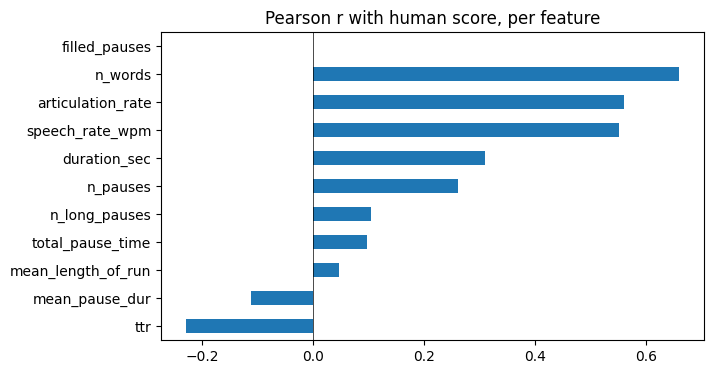

In [6]:
corr = feats[FEATURES + ["score"]].corr(numeric_only=True)["score"].drop("score").sort_values()
ax = corr.plot.barh(figsize=(7, 4))
ax.set_title("Pearson r with human score, per feature")
ax.axvline(0, color="k", lw=0.5);
print(corr.round(3))

## Step 6 — Models: dumb baselines vs Ridge on all features

Three contenders, per the design doc's *"dumb baselines in every table, always"* rule:

1. **Mean predictor** — predicts the average score for everyone. The floor: any model that
   can't beat it has learned nothing.
2. **Word-count Ridge** — one feature (`n_words`). If 11 features barely beat one, feature
   engineering wasn't worth it. *This is the most important comparison in the notebook.*
3. **Full Ridge** — all 11 features, standardised. Ridge = linear regression with an L2
   penalty that shrinks coefficients; with 11 correlated features and ~100 rows, plain OLS
   would overfit and Ridge is the textbook fix.

**Why `cross_val_predict` instead of a train/test split?** With 100 rows, a 25-row test set
gives extremely noisy metrics (one lucky speaker shifts kappa visibly). 5-fold
cross-validation trains on 80 and predicts the held-out 20, rotating until *every* response
has an out-of-fold prediction — all 100 rows contribute to the evaluation, and no response is
ever predicted by a model that saw it during training.

**Why standardise inside the pipeline?** Features live on wildly different scales (wpm ≈ 100,
ttr ≈ 0.5). Ridge's penalty is scale-sensitive, so features must be standardised — but fitting
the scaler on *all* data before splitting would leak test-fold statistics into training
(**data leakage**). Wrapping `StandardScaler` in the pipeline means it's re-fit on each
training fold only. Subtle, and exactly the kind of thing evaluation science exists to catch.

In [7]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X_all = feats[FEATURES].to_numpy()
X_wc = feats[["n_words"]].to_numpy()
y = feats.score.to_numpy()
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

pipe = lambda: make_pipeline(StandardScaler(), Ridge(alpha=1.0))

preds = {
    "mean predictor": np.full_like(y, y.mean()),
    "word-count Ridge": cross_val_predict(pipe(), X_wc, y, cv=cv),
    "full Ridge (11 feats)": cross_val_predict(pipe(), X_all, y, cv=cv),
}
print({k: f"{len(v)} predictions" for k, v in preds.items()})

{'mean predictor': '100 predictions', 'word-count Ridge': '100 predictions', 'full Ridge (11 feats)': '100 predictions'}


## Step 7 — Evaluation: correlation, error, and weighted kappa

Four metrics, each answering a different question:

- **Pearson r** — do predictions move linearly with human scores? (The headline metric in
  most automated-scoring papers.)
- **Spearman ρ** — do they at least *rank* speakers correctly, even if miscalibrated?
- **MAE / RMSE** — how far off are we, in score points? RMSE punishes large misses harder.
- **Quadratic Weighted Kappa (QWK)** — the assessment-industry standard. It measures
  agreement on the *ordinal scale* (predictions rounded to the 0.5-step grid), corrected for
  chance agreement, with disagreements penalised by their *squared* distance — calling a B1 a
  B2 is mildly wrong, calling a B1 a C1 is 4× worse. "Corrected for chance" is why QWK is
  brutal where accuracy flatters: the mean predictor gets QWK ≈ 0 *by construction*.

To compute QWK we snap continuous predictions to the human grid (round to nearest 0.5, clip
to the observed range) and code each 0.5 step as an integer class.

In [8]:
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import cohen_kappa_score, mean_absolute_error, mean_squared_error

def to_grid(scores: np.ndarray) -> np.ndarray:
    """Snap to the human 0.5-step grid and code as integer classes (x2)."""
    snapped = np.clip(np.round(scores * 2) / 2, y.min(), y.max())
    return (snapped * 2).astype(int)

def evaluate(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    return {
        "pearson_r": pearsonr(y_true, y_pred)[0],
        "spearman_rho": spearmanr(y_true, y_pred)[0],
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "QWK": cohen_kappa_score(to_grid(y_true), to_grid(y_pred), weights="quadratic"),
    }

results = pd.DataFrame({name: evaluate(y, p) for name, p in preds.items()}).T
results.round(3)

/tmp/claude-504/ipykernel_39817/2486254308.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  "pearson_r": pearsonr(y_true, y_pred)[0],
/tmp/claude-504/ipykernel_39817/2486254308.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  "spearman_rho": spearmanr(y_true, y_pred)[0],


,pearson_r,spearman_rho,MAE,RMSE,QWK
mean predictor,NaN,NaN,0.558,0.731,0.000
word-count Ridge,0.648,0.674,0.418,0.557,0.580
full Ridge (11 feats),0.671,0.667,0.433,0.543,0.621


### Confusion matrix by CEFR band

Metrics compress everything into one number; the confusion matrix shows *where* the model is
wrong. Rows = human band, columns = predicted band (integer part of the score, 1 = A1 …
5 = C1). Two patterns to look for:

- **Regression to the mean** — extreme bands (A2, C1) dragged toward B1/B2. Near-universal in
  regression scorers and a real fairness issue: it systematically *over*-scores weak speakers
  and *under*-scores strong ones.
- **Off-by-more-than-one errors** — a scorer that's never more than one band out is usable;
  one that confuses A2 with B2 is not.

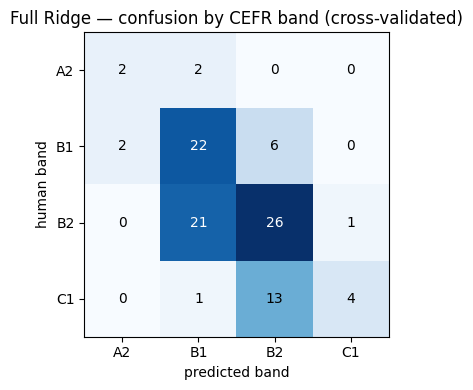

In [9]:
import matplotlib.pyplot as plt

BAND_NAMES = {1: "A1", 2: "A2", 3: "B1", 4: "B2", 5: "C1"}
band = lambda s: np.clip(np.floor(s), 1, 5).astype(int)

true_b = band(y)
pred_b = band(preds["full Ridge (11 feats)"])
labels = sorted(set(true_b) | set(pred_b))
cm = pd.crosstab(true_b, pred_b).reindex(index=labels, columns=labels, fill_value=0)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels)), [BAND_NAMES[b] for b in labels])
ax.set_yticks(range(len(labels)), [BAND_NAMES[b] for b in labels])
ax.set_xlabel("predicted band"); ax.set_ylabel("human band")
ax.set_title("Full Ridge — confusion by CEFR band (cross-validated)")
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm.iloc[i, j], ha="center", va="center",
                color="white" if cm.iloc[i, j] > cm.values.max() / 2 else "black")
plt.tight_layout()

## Step 8 — What did the model actually learn?

Ridge coefficients on standardised features are directly comparable: each says *"one standard
deviation more of this feature shifts the predicted score by this many points, holding the
rest constant."* Check them against linguistic common sense:

- speech rate / words / length of run should push **up**
- long pauses and pause time should push **down**
- `filled_pauses` should be near zero — not because filled pauses don't matter (they do!) but
  because Whisper erased most of them before the feature ever saw the data. **An ASR
  limitation silently became a feature limitation** — the exact propagation chain the
  error-analysis report exists to document.

total_pause_time     -0.276
filled_pauses         0.000
mean_length_of_run    0.066
mean_pause_dur        0.070
speech_rate_wpm       0.124
n_long_pauses         0.158
n_words               0.177
n_pauses              0.178
ttr                   0.184
duration_sec          0.213
articulation_rate     0.225
dtype: float64


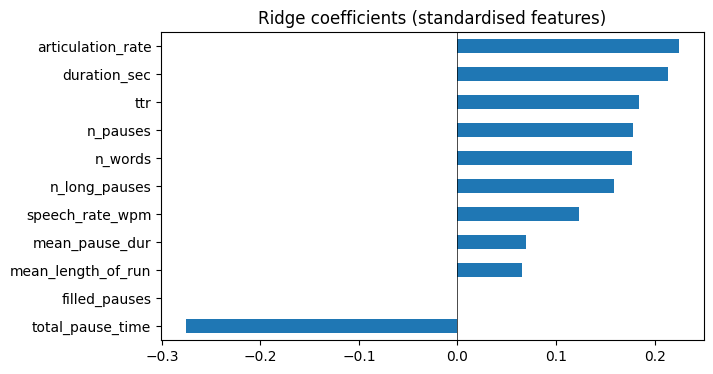

In [10]:
final = pipe().fit(X_all, y)
coefs = pd.Series(final.named_steps["ridge"].coef_, index=FEATURES).sort_values()
ax = coefs.plot.barh(figsize=(7, 4))
ax.set_title("Ridge coefficients (standardised features)")
ax.axvline(0, color="k", lw=0.5);
print(coefs.round(3))

## Step 9 — What we learned, and what's next

Read your numbers against these reference points:

- **QWK:** 0.4–0.6 from timing-only features on 100 responses would be entirely respectable —
  published end-to-end graders on this kind of task reach ~0.7+ using far richer inputs.
  Below 0.3 means something is broken (check the correlation chart in Step 5b first).
- **The gap between word-count Ridge and full Ridge** is the honest measure of what ten
  features bought over one. If it's small, say so plainly in the report — that *is* a finding,
  and a common one in fluency research (quantity correlates startlingly well with proficiency).
- **The mean predictor's MAE** calibrates everything: on a 0–6 scale where most speakers sit
  within one point of the mean, an MAE of ~0.6 is achievable *knowing nothing*. Beating it by
  0.1–0.2 points is real progress; matching it is failure dressed in metrics.

**Deliberate limitations of this slice** (each becomes real work in later notebooks):

1. Whisper transcripts are unvalidated — notebook 02 computes WER against the gold STM
   transcripts and adds acoustic/prosody features (pitch, intensity) from the raw audio.
2. No text/content features — embeddings, relevance-to-question, LLM rubric scoring arrive in
   notebook 03 alongside Random Forest and the PyTorch MLP.
3. 100 responses, one part — scaling to all 438 P3 speakers (and other parts) tightens every
   confidence interval.
4. No fairness slices yet — audio quality and proficiency-band analyses arrive in notebook 04
   with the full evaluation report.

> **Licence reminder before committing:** outputs above are aggregates only. If you added
> exploratory cells that print transcripts or per-response rows, clear all outputs first:
> `jupyter nbconvert --clear-output --inplace notebooks/01_vertical_slice.ipynb`